# Somatic Variant Analysis — HCC1143 Breast Cancer Cell Line

GATK Mutect2 tumor-normal → FilterMutectCalls → 5-layer annotation → LLM interpretation.

**Data**: chr17:7M–20M | **Tumor**: HCC1143 breast cancer | **Caller**: Mutect2 v4.4

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 120

ANNOTATED_TSV = '../../results/somatic/annotated/annotated.tsv'
FILTER_STATS  = '../../results/somatic/filtered/filtering_stats.tsv'
INTERPRETED   = '../../results/somatic/annotated/interpreted.json'

print('Loading annotated somatic variants...')
df = pd.read_csv(ANNOTATED_TSV, sep='\t', low_memory=False)
print(f'Loaded {len(df)} PASS somatic variants')
df.head(3)

Loading annotated somatic variants...
Loaded 26 PASS somatic variants


,chrom,pos,ref,alt,filter,gene_symbol,ensembl_gene_id,gene_biotype,transcript_id,is_canonical,...,civic_evidence_type,civic_clinical_significance,civic_drug,civic_cancer_type,vaf,depth,genotype,existing_variation,regulatory_id,af_1kg
0,chr17,2394409,G,T,PASS,METTL16,ENSG00000127804,protein_coding,ENST00000263092,NO,...,.,.,.,.,0.016,32,somatic,.,.,.
1,chr17,4632718,G,A,PASS,MED11,ENSG00000161920,protein_coding,ENST00000293777,NO,...,.,.,.,.,0.024,20,somatic,.,.,.
2,chr17,5541887,C,T,PASS,.,.,.,.,.,...,.,.,.,.,0.043,32,somatic,.,.,.


In [2]:
## Setup complete — data loaded above

## 1. Overview — what's in the callset?

Before diving into biology, always do a sanity check: how many variants, what types, basic stats.

In [3]:
print('=== Callset Overview ===')
print(f'Total PASS variants: {len(df)}')
print(f'\nVariant types:')
snp_count   = ((df.ref.str.len() == 1) & (df.alt.str.len() == 1)).sum()
indel_count = len(df) - snp_count
print(f'  SNPs:   {snp_count}')
print(f'  Indels: {indel_count}')

print(f'\nImpact distribution:')
print(df.impact.value_counts().to_string())

print(f'\nVAF summary (tumor allele frequency):')
vaf = pd.to_numeric(df.vaf, errors='coerce').dropna()
print(f'  Median VAF: {vaf.median():.3f}')
print(f'  Mean VAF:   {vaf.mean():.3f}')
print(f'  VAF range:  {vaf.min():.3f} – {vaf.max():.3f}')
print(f'  Clonal (VAF>0.2): {(vaf > 0.2).sum()}')
print(f'  Subclonal (VAF≤0.2): {(vaf <= 0.2).sum()}')

=== Callset Overview ===
Total PASS variants: 26

Variant types:
  SNPs:   26
  Indels: 0

Impact distribution:
impact
.           17
MODIFIER     8
HIGH         1

VAF summary (tumor allele frequency):
  Median VAF: 0.034
  Mean VAF:   0.043
  VAF range:  0.000 – 0.125
  Clonal (VAF>0.2): 0
  Subclonal (VAF≤0.2): 26


## 2. Variant Allele Frequency (VAF) Distribution

VAF tells us about tumor clonality:
- **Clonal variants** (VAF ~0.3–0.5 for het in diploid tumor): present in most/all tumor cells — likely early events
- **Subclonal variants** (VAF < 0.1): present in a subset of tumor cells — later events or minor clones
- **Very low VAF** (< 0.05): borderline; may be real subclonal or residual artifacts

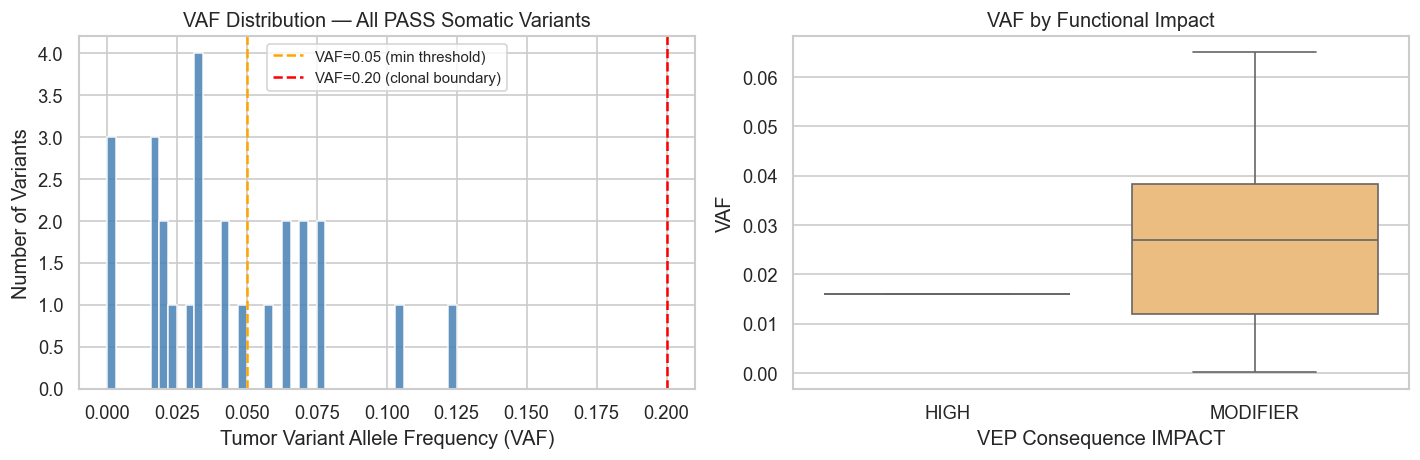

Figure saved.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(vaf, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(0.05, color='orange', linestyle='--', label='VAF=0.05 (min threshold)')
axes[0].axvline(0.20, color='red',    linestyle='--', label='VAF=0.20 (clonal boundary)')
axes[0].set_xlabel('Tumor Variant Allele Frequency (VAF)')
axes[0].set_ylabel('Number of Variants')
axes[0].set_title('VAF Distribution — All PASS Somatic Variants')
axes[0].legend(fontsize=9)

# VAF by consequence IMPACT
impact_vaf = df.copy()
impact_vaf['vaf_num'] = pd.to_numeric(impact_vaf['vaf'], errors='coerce')
impact_vaf = impact_vaf[impact_vaf['impact'].notna() & impact_vaf['vaf_num'].notna()]
order = ['HIGH', 'MODERATE', 'LOW', 'MODIFIER']
present = [o for o in order if o in impact_vaf.impact.unique()]
impact_vaf_filt = impact_vaf[impact_vaf.impact.isin(present)]
sns.boxplot(data=impact_vaf_filt, x='impact', y='vaf_num', order=present,
            palette='RdYlGn_r', ax=axes[1])
axes[1].set_xlabel('VEP Consequence IMPACT')
axes[1].set_ylabel('VAF')
axes[1].set_title('VAF by Functional Impact')

plt.tight_layout()
plt.savefig('../../results/somatic/annotated/vaf_distribution.png', bbox_inches='tight')
plt.show()
print('Figure saved.')

## 3. Consequence Type Breakdown

VEP assigns a Sequence Ontology (SO) term to each variant based on its effect on transcripts.
Understanding consequence type is the first step in prioritizing variants for clinical interpretation.

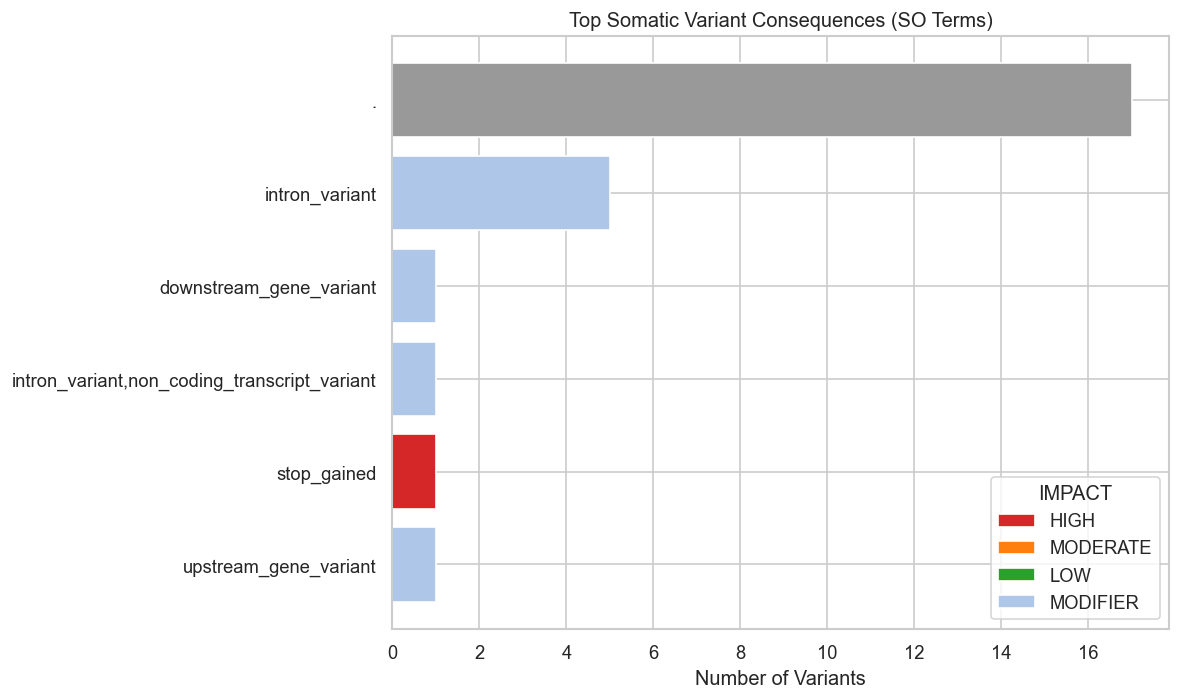

In [5]:
IMPACT_COLORS = {
    'HIGH':     '#d62728',
    'MODERATE': '#ff7f0e',
    'LOW':      '#2ca02c',
    'MODIFIER': '#aec7e8',
}

cons_df = df.explode('consequence') if df['consequence'].str.contains(',').any() else df.copy()
cons_counts = cons_df.groupby(['consequence','impact']).size().reset_index(name='count')
cons_counts = cons_counts.sort_values('count', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [IMPACT_COLORS.get(row['impact'], '#999') for _, row in cons_counts.iterrows()]
bars = ax.barh(cons_counts['consequence'], cons_counts['count'], color=colors)
ax.set_xlabel('Number of Variants')
ax.set_title('Top Somatic Variant Consequences (SO Terms)')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=i) for i, c in IMPACT_COLORS.items()]
ax.legend(handles=legend_elements, title='IMPACT', loc='lower right')
plt.tight_layout()
plt.savefig('../../results/somatic/annotated/consequence_breakdown.png', bbox_inches='tight')
plt.show()

## 4. CADD Score Distribution

CADD phred score integrates 60+ annotation features into a single deleteriousness metric.
Threshold interpretation: phred ≥ 20 = top 1% most deleterious in the genome.

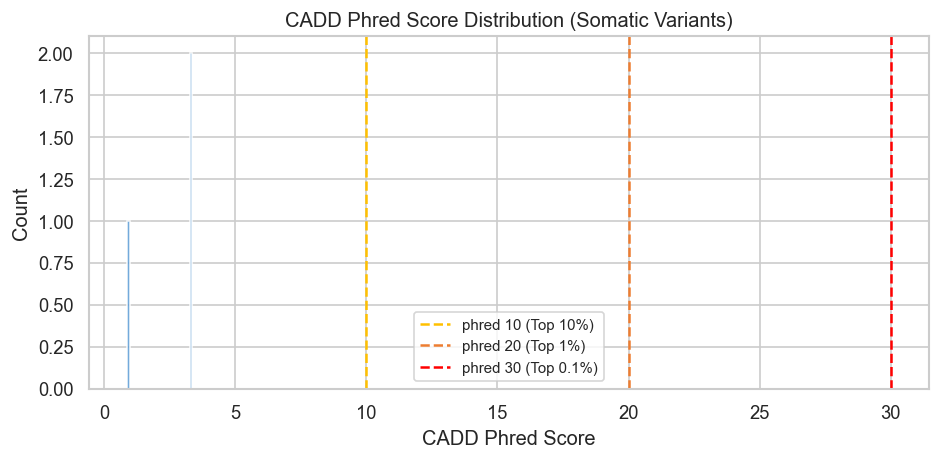

Variants with CADD phred ≥ 20: 0 (0.0%)
Variants with CADD phred ≥ 30: 0


In [6]:
cadd = pd.to_numeric(df['cadd_phred'], errors='coerce').dropna()

if len(cadd) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(cadd, bins=30, color='#5B9BD5', edgecolor='white', alpha=0.85)
    for threshold, label, color in [(10, 'Top 10%', '#FFC000'), (20, 'Top 1%', '#ED7D31'), (30, 'Top 0.1%', '#FF0000')]:
        ax.axvline(threshold, color=color, linestyle='--', linewidth=1.5, label=f'phred {threshold} ({label})')
    ax.set_xlabel('CADD Phred Score')
    ax.set_ylabel('Count')
    ax.set_title('CADD Phred Score Distribution (Somatic Variants)')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('../../results/somatic/annotated/cadd_distribution.png', bbox_inches='tight')
    plt.show()
    print(f'Variants with CADD phred ≥ 20: {(cadd >= 20).sum()} ({(cadd >= 20).mean()*100:.1f}%)')
    print(f'Variants with CADD phred ≥ 30: {(cadd >= 30).sum()}')
else:
    print('No CADD scores available (API may not have been run). See docs/skipped_steps_explainer.ipynb.')

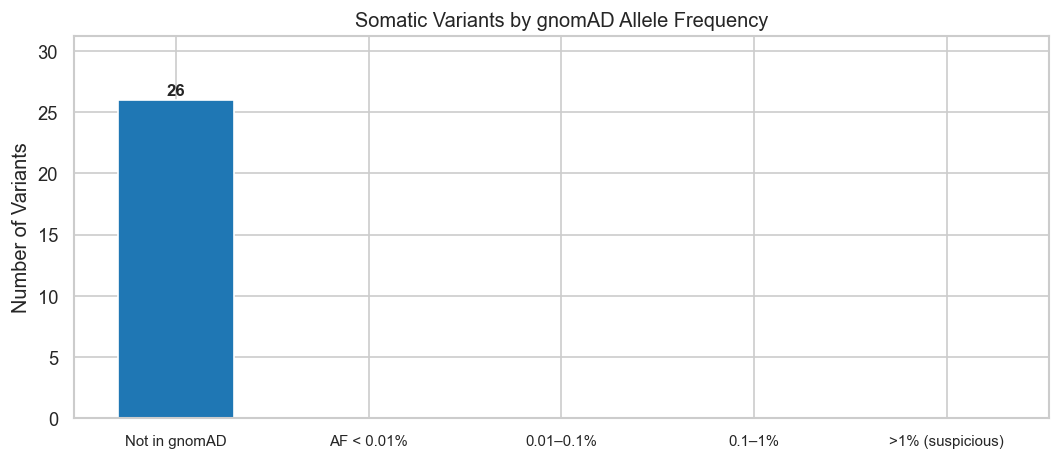

Note: >1% AF variants should be reviewed — may be germline polymorphisms.


In [7]:
gnomad_af = pd.to_numeric(df['gnomad_af'], errors='coerce')

categories = [
    ('Not in gnomAD',     gnomad_af.isna().sum()),
    ('AF < 0.01%',        ((gnomad_af < 0.0001) & gnomad_af.notna()).sum()),
    ('0.01–0.1%',         ((gnomad_af >= 0.0001) & (gnomad_af < 0.001)).sum()),
    ('0.1–1%',            ((gnomad_af >= 0.001)  & (gnomad_af < 0.01)).sum()),
    ('>1% (suspicious)',  (gnomad_af >= 0.01).sum()),
]
labels = [c[0] for c in categories]
counts = [c[1] for c in categories]
bar_colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, counts, color=bar_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, counts):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of Variants')
ax.set_title('Somatic Variants by gnomAD Allele Frequency')
ax.tick_params(axis='x', labelsize=9)
ax.set_ylim(0, max(counts) * 1.2)
plt.tight_layout()
plt.savefig('../../results/somatic/annotated/gnomad_af_distribution.png', bbox_inches='tight')
plt.show()
print('Note: >1% AF variants should be reviewed — may be germline polymorphisms.')

In [8]:
# (old pie chart cell removed — see bar chart above)

## 6. CIViC Actionable Variants

CIViC evidence links somatic variants to therapeutic interventions.
Evidence level A = prospective clinical trial; B = retrospective study.

In [9]:
civic_df = df[df['civic_evidence_level'].notna() & (df['civic_evidence_level'] != '.')].copy()
print(f'Variants with CIViC evidence: {len(civic_df)}')

if len(civic_df) > 0:
    display_cols = ['gene_symbol', 'hgvsp', 'consequence', 'vaf',
                    'civic_evidence_level', 'civic_evidence_type',
                    'civic_drug', 'civic_cancer_type']
    available = [c for c in display_cols if c in civic_df.columns]
    print('\nActionable variants:')
    print(civic_df[available].to_string(index=False))
else:
    print('No CIViC evidence found for this callset.')
    print('This is expected for the tutorial chr17 subset — full WGS data would yield more hits.')

Variants with CIViC evidence: 0
No CIViC evidence found for this callset.
This is expected for the tutorial chr17 subset — full WGS data would yield more hits.


## 7. High-Priority Variant Table

Filtered to HIGH/MODERATE impact variants. This is the triage-ready table.
Columns: gene, HGVS, consequence, VAF, gnomAD AF, CADD phred, ClinVar.

In [10]:
priority = df[df['impact'].isin(['HIGH', 'MODERATE'])].copy()
priority['vaf'] = pd.to_numeric(priority['vaf'], errors='coerce')
priority = priority.sort_values('vaf', ascending=False)

display_cols = [
    'gene_symbol', 'hgvsp', 'hgvsc', 'consequence', 'impact',
    'vaf', 'cadd_phred', 'gnomad_af',
    'clinvar_clnsig', 'clinvar_review_stars',
    'exon', 'sift_pred', 'polyphen_pred'
]
available = [c for c in display_cols if c in priority.columns]

print(f'HIGH/MODERATE impact PASS variants: {len(priority)}')
print()
pd.set_option('display.max_colwidth', 40)
pd.set_option('display.max_rows', 50)
priority[available].reset_index(drop=True)

HIGH/MODERATE impact PASS variants: 1



,gene_symbol,hgvsp,hgvsc,consequence,impact,vaf,cadd_phred,gnomad_af,clinvar_clnsig,clinvar_review_stars,exon,sift_pred,polyphen_pred
0,NT5C3B,.,.,stop_gained,HIGH,0.016,.,.,.,.,.,.,.


## 8. Agentic Interpretation Results

Load and display the Claude-generated clinical interpretations from the agent layer.

In [11]:
import json
from pathlib import Path

interp_path = Path(INTERPRETED)
if interp_path.exists():
    with open(interp_path) as f:
        interp_data = json.load(f)
    
    print(f"Model: {interp_data['metadata']['model']}")
    print(f"Variants interpreted: {interp_data['metadata']['n_llm_interpreted']}")
    print(f"Run date: {interp_data['metadata']['run_date']}")
    print()
    
    for v in interp_data['variants']:
        if v['tier'] not in ('NOT_INTERPRETED', 'PASSENGER', 'ARTIFACT'):
            print(f"{'='*70}")
            print(f"VARIANT: {v['gene']} {v['hgvsp']}")
            print(f"TIER:    {v['tier']}")
            print(f"HGVS:    {v['hgvsc']} | {v['hgvsg']}")
            print()
            print(f"INTERPRETATION:")
            print(f"  {v['interpretation']}")
            print()
            if v['evidence']:
                print('EVIDENCE:')
                for e in v['evidence']:
                    print(f'  • {e}')
            print()
else:
    print(f'Interpreted variants file not found at {INTERPRETED}')
    print('Run: python agent/variant_interpreter.py --tsv results/somatic/annotated/annotated.tsv --type somatic --top 10')

Model: claude-haiku-4-5-20251001
Variants interpreted: 18
Run date: 2026-05-09T07:09:48.182379

VARIANT: NT5C3B .
TIER:    VUS_SOMATIC
HGVS:    . | NC_000017.11:g.39988669G>A

INTERPRETATION:
  This is a stop-gained variant (E/*) in NT5C3B, a nucleotidase involved in nucleotide metabolism. The variant results in premature termination of the protein, likely causing loss of function. The VAF of 1.6% at modest sequencing depth (31×) suggests a minor subclonal population, though the low depth limits confidence in VAF precision. No established cancer association, CIViC evidence, or ClinVar annotation is available for this variant. Without functional data or recurrent evidence in cancer cohorts, the oncogenic significance of NT5C3B loss in this tumor context cannot be determined.

EVIDENCE:
  • High-impact consequence (stop_gained, E/*) predicts loss of function
  • NT5C3B has no established role as a cancer driver gene in major oncology databases (no CIViC entries)
  • VAF of 1.6% indicates